In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 

# Euler

In [2]:
#Euler - need to update position, velocity, and accel in both x and y
def Euler(x,y,vx,vy,time,dt):
    '''
    x, y, vx, and vy are the initial params given. Time is how long I want the loop to go for and dt is the step size. 
    '''

    x_vals = [x]
    y_vals = [y]
    vx_vals = [vx]
    vy_vals = [vy]
    
    #calculate initial energy
    r = np.sqrt(x**2 + y**2)
    e = 0.5*(vx**2 + vy**2) - G*M/r
    
    e_vals = [e]
  
    steps = int(time/dt) 
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first

        #accel in x and y from position
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3

        x_new  = x + vx*dt
        y_new  = y + vy*dt
        vx_new = vx + ax*dt
        vy_new = vy + ay*dt

        #calc energies
        r_new = np.sqrt(x_new**2 + y_new**2)
        e = 0.5*(vx_new**2 + vy_new**2) - G*M/r_new
        
        #updating params 
        x = x_new
        y = y_new
        vx = vx_new
        vy = vy_new
        
        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)
        e_vals.append(e)

    t_vals = np.linspace(0, time, steps + 1)

    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), np.array(e_vals), t_vals

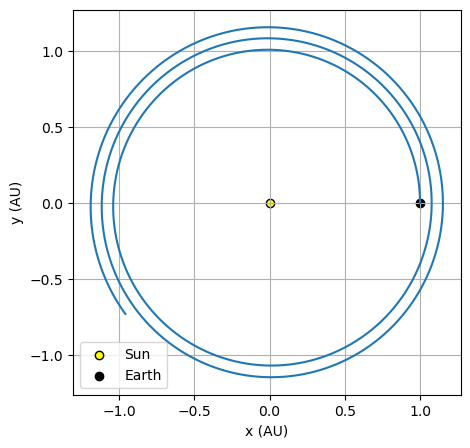

In [3]:
#testing Euler
#Orbital mech eqns - but need to do in x and y. Using params given by hw
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,vcirc,3,0.001)

plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Earth",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.savefig("Euler_orbit.png",dpi=300)
plt.show()

In [4]:
#Figure stuff
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Euler Orbit')

#Plotting stuff
earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.grid()
ax.legend()

def init():
    earth.set_data([], [])
    trail.set_data([], [])
    return earth, trail

#Update function
frame_step = 10
def update(frame):
    idx = frame * frame_step #frame steps
    earth.set_data([x[idx]], [y[idx]]) #earth position updates
    trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
    return earth, trail

#Animation
total_frames = len(x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
plt.close() 

#save as gif
ani.save('euler.gif', writer='pillow', fps=30)

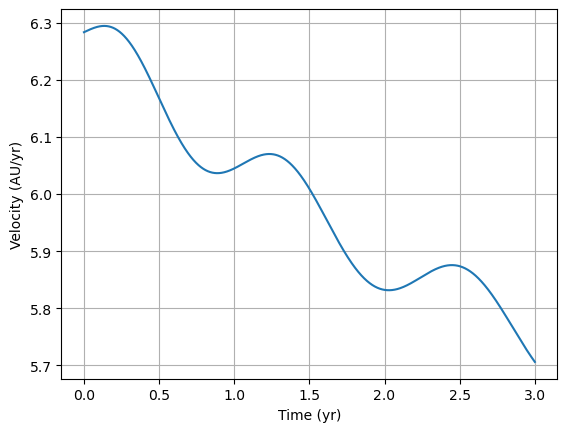

In [5]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,vcirc,3,0.001)

plt.plot(t, np.sqrt(vx**2+vy**2))
plt.xlabel("Time (yr)")
plt.ylabel("Velocity (AU/yr)")
plt.grid()
plt.savefig("Euler_velocity.png",dpi=300)
plt.show()

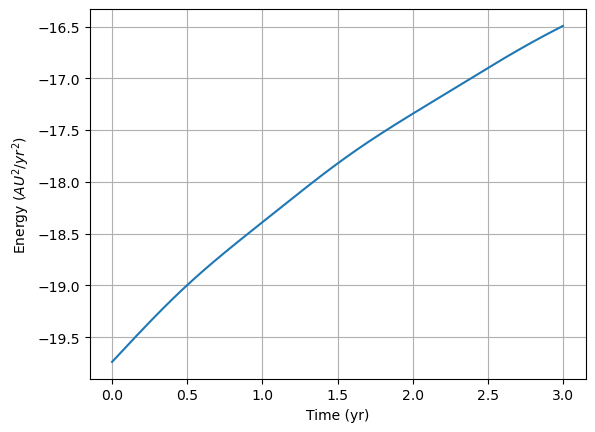

In [6]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Euler_energy.png",dpi=300)
plt.show()

In [7]:
e[0], e[-1]

(np.float64(-19.739208802178716), np.float64(-16.4936581790178))

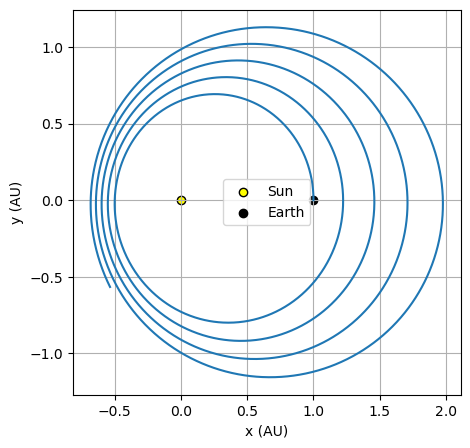

In [8]:
#0.8*vcirc
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,0.8*vcirc,5,0.001)

plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Earth",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.savefig("Euler_orbit5.png",dpi=300)
plt.show()

In [9]:
#Figure stuff
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1.5, 2)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Euler Orbit with v=0.8vcirc')

#Plotting stuff
earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.grid()
ax.legend()

def init():
    earth.set_data([], [])
    trail.set_data([], [])
    return earth, trail

#Update function
frame_step = 10 
def update(frame):
    idx = frame * frame_step #frame steps
    earth.set_data([x[idx]], [y[idx]]) #earth position updates
    trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
    return earth, trail

#Animation
total_frames = len(x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
plt.close() 

#save as gif
ani.save('euler5.gif', writer='pillow', fps=30)

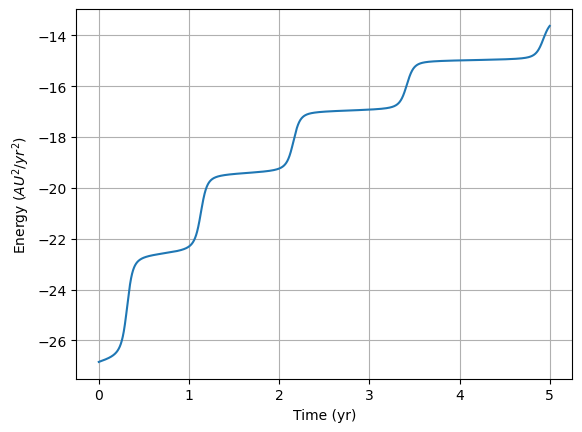

In [10]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Euler_5energy.png",dpi=300)
plt.show()

# Leapfrog

In [11]:
#Leapfrog
def Leapfrog(x,y,vx,vy,time,dt):

    x_vals = [x]
    y_vals = [y]
    vx_vals = [vx]
    vy_vals = [vy]
  
    #calculate initial energy
    r = np.sqrt(x**2 + y**2)
    e = 0.5*(vx**2 + vy**2) - G*M/r
    
    e_vals = [e]

    steps = int(time/dt)
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3
        
        #first kick (half-interval)
        vx_fhalf = vx + 0.5*ax*dt
        vy_fhalf = vy + 0.5*ay*dt
    
        #drift from first kick 
        x_new = x + vx_fhalf*dt
        y_new = y + vy_fhalf*dt

        #accel and energy from drift
        r_new = np.sqrt(x_new**2 + y_new**2)
        ax_drift = -G*M*x_new/r_new**3
        ay_drift = -G*M*y_new/r_new**3
    
        #second kick (half-interval) - this makes the full time step
        vx_shalf = vx_fhalf + 0.5*ax_drift*dt
        vy_shalf = vy_fhalf + 0.5*ay_drift*dt
 
        #calc energies
        e = 0.5*(vx_shalf**2 + vy_shalf**2) - G*M/r_new
    
        #updating params 
        x = x_new
        y = y_new
        vx = vx_shalf
        vy = vy_shalf

        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)
        e_vals.append(e)

    t_vals = np.linspace(0, steps*dt, steps + 1)
    
    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), np.array(e_vals), t_vals

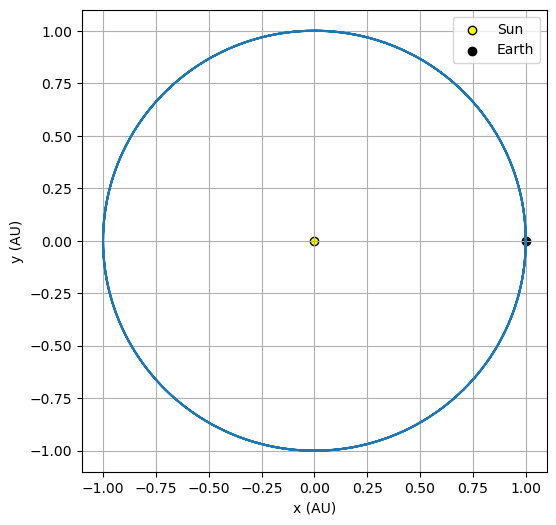

In [12]:
#testing leapfrog
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,vcirc,3,0.001)

plt.figure(figsize=(6,6))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Earth",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.savefig("Leapfrog_orbit.png",dpi=300)
plt.show()

In [13]:
#Figure stuff
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Leapfrog Orbit')

#Plotting stuff
earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.grid()
ax.legend()

def init():
    earth.set_data([], [])
    trail.set_data([], [])
    return earth, trail

#Update function
frame_step = 10
def update(frame):
    idx = frame * frame_step #frame steps
    earth.set_data([x[idx]], [y[idx]]) #earth position updates
    trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
    return earth, trail

#Animation
total_frames = len(x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
plt.close() 

#save as gif
ani.save('leapfrog.gif', writer='pillow', fps=30)

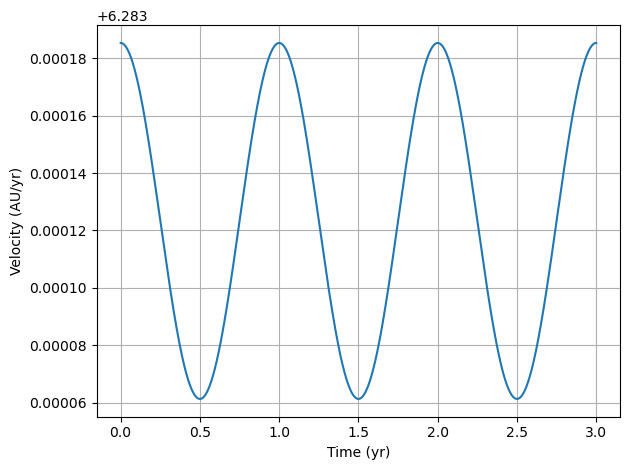

In [19]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,vcirc,3,0.001)

plt.plot(t, np.sqrt(vx**2+vy**2))
plt.xlabel("Time (yr)")
plt.ylabel("Velocity (AU/yr)")
plt.grid()
plt.tight_layout()
plt.savefig("Leapfrog_velocity.png",dpi=300)
plt.show()

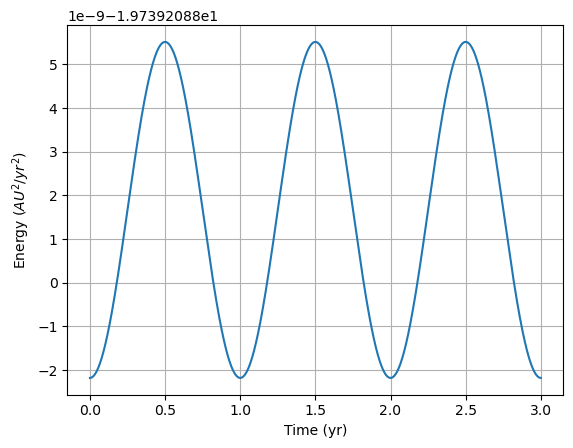

In [20]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Leapfrog_energy.png",dpi=300)
plt.show()

In [21]:
e[0],e[-1]

(np.float64(-19.739208802178716), np.float64(-19.73920880217888))

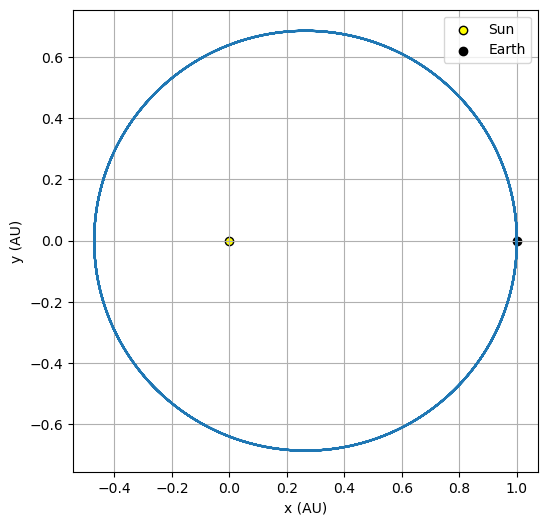

In [22]:
#0.8*vcirc
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,0.8*vcirc,5,0.001)

plt.figure(figsize=(6,6))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Earth",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.savefig("Leapfrog_orbit5.png",dpi=300)
plt.show()

In [23]:
#Figure stuff
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Leapfrog Orbit with v=0.8vcirc')

#Plotting stuff
earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.grid()
ax.legend()

def init():
    earth.set_data([], [])
    trail.set_data([], [])
    return earth, trail

#Update function
frame_step = 10
def update(frame):
    idx = frame * frame_step #frame steps
    earth.set_data([x[idx]], [y[idx]]) #earth position updates
    trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
    return earth, trail

#Animation
total_frames = len(x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
plt.close() 

#save as gif
ani.save('leapfrog5.gif', writer='pillow', fps=30)

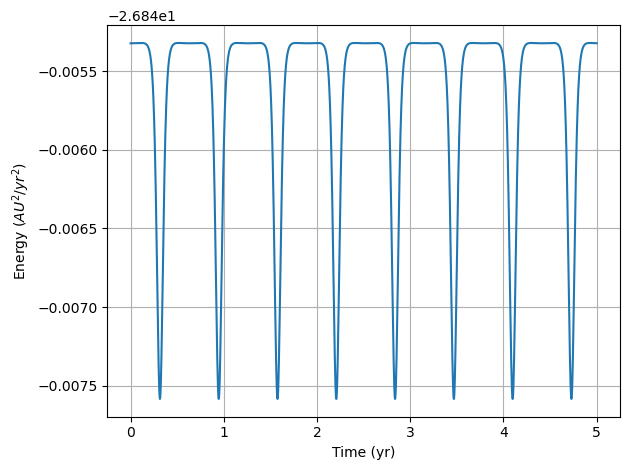

In [24]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.tight_layout()
plt.savefig("Leapfrog_5energy.png",dpi=300)
plt.show()

# Comparison plots

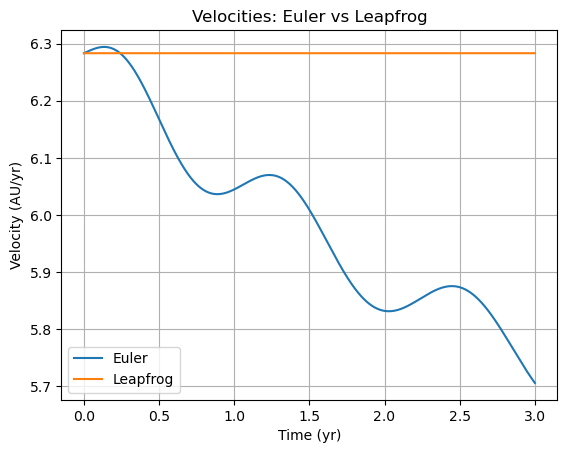

In [25]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)


xE,yE,vxE,vyE,eE,t = Euler(x,y,0,vcirc,3,0.001)
xL,yL,vxL,vyL,eL,t = Leapfrog(x,y,0,vcirc,3,0.001)


plt.plot(t, np.sqrt(vxE**2+vyE**2),label="Euler")
plt.plot(t, np.sqrt(vxL**2+vyL**2),label="Leapfrog")
plt.xlabel("Time (yr)")
plt.ylabel("Velocity (AU/yr)")
plt.title("Velocities: Euler vs Leapfrog")
plt.grid()
plt.legend()
plt.savefig("E_L_Vel.png",dpi=300)
plt.show()

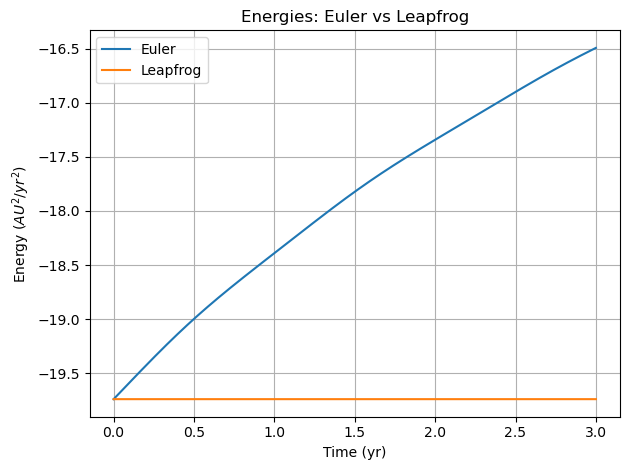

In [26]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)


xE,yE,vxE,vyE,eE,t = Euler(x,y,0,vcirc,3,0.001)
xL,yL,vxL,vyL,eL,t = Leapfrog(x,y,0,vcirc,3,0.001)


plt.plot(t, eE,label="Euler")
plt.plot(t, eL,label="Leapfrog")
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.title("Energies: Euler vs Leapfrog")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("E_L_En.png",dpi=300)
plt.show()

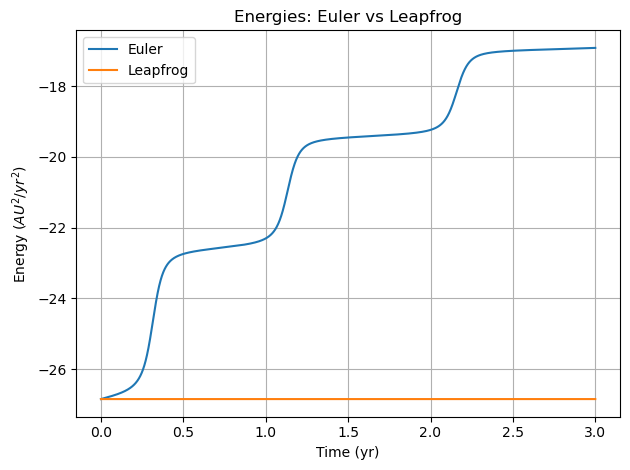

In [27]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)


xE,yE,vxE,vyE,eE,t = Euler(x,y,0,vcirc*0.8,3,0.001)
xL,yL,vxL,vyL,eL,t = Leapfrog(x,y,0,vcirc*0.8,3,0.001)


plt.plot(t, eE,label="Euler")
plt.plot(t, eL,label="Leapfrog")
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.title("Energies: Euler vs Leapfrog")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("E_L_5En.png",dpi=300)
plt.show()

# Voyager

In [6]:
#some constants out front first
G = 4*np.pi**2 #AU^3/Msunyr^2
M_sun = 1.0 #solar mass

M_earth = 3.003e-6 #Msun
M_jupiter = 0.0009543 #Msun

eps = 1e-6  #helps with divide by zero issues

#conversions for later
dist_conver = 1.496e8 #AU to year
vel_conver = 4.743 #AU/yr to km/s

In [7]:
#Sun acts on Jupiter and Earth in their orbits
def accel_sun(x, y):
    r2 = x*x + y*y + eps
    r3 = r2*np.sqrt(r2)
    ax = -G*M_sun*x/r3
    ay = -G*M_sun*y/r3
    return ax, ay

#Acceleration on Voyager
def accel_voyager(x, y, x0, y0, M):
    dx = x - x0
    dy = y - y0
    r2 = dx*dx + dy*dy + eps
    r3 = r2*np.sqrt(r2)
    ax = -G*M*dx/r3
    ay = -G*M*dy/r3
    return ax, ay

#New Leapfrog for this part
def Leapfrog_4body(xV, yV, vxV, vyV, xE, yE, vxE, vyE, xJ, yJ, vxJ, vyJ, time, dt):

    steps = int(time / dt)

    xV_vals, yV_vals = [xV], [yV] #Voyager initial position
    xE_vals, yE_vals = [xE], [yE] #Earth initial position
    xJ_vals, yJ_vals = [xJ], [yJ] #Jupiter initial position

    vxV_vals, vyV_vals = [vxV], [vyV] #Voyager initial velocity

    for _ in range(steps):
        #Earth & Jupiter only feel Sun
        axE, ayE = accel_sun(xE, yE)
        axJ, ayJ = accel_sun(xJ, yJ)

        #Voyager feels all (Sun, Jupiter, and Earth)
        axV_s, ayV_s = accel_sun(xV, yV)
        axV_e, ayV_e = accel_voyager(xV, yV, xE, yE, M_earth)
        axV_j, ayV_j = accel_voyager(xV, yV, xJ, yJ, M_jupiter)

        #add the effects of each velocity of the bodies
        axV = axV_s + axV_e + axV_j
        ayV = ayV_s + ayV_e + ayV_j

        #first kick
        vxE_h = vxE + 0.5*axE*dt
        vyE_h = vyE + 0.5*ayE*dt

        vxJ_h = vxJ + 0.5*axJ*dt
        vyJ_h = vyJ + 0.5*ayJ*dt

        vxV_h = vxV + 0.5*axV*dt
        vyV_h = vyV + 0.5*ayV*dt

        #drift
        xE_new = xE + vxE_h*dt
        yE_new = yE + vyE_h*dt

        xJ_new = xJ + vxJ_h*dt
        yJ_new = yJ + vyJ_h*dt

        xV_new = xV + vxV_h*dt
        yV_new = yV + vyV_h*dt

        #calc accels again
        axE_new, ayE_new = accel_sun(xE_new, yE_new)
        axJ_new, ayJ_new = accel_sun(xJ_new, yJ_new)

        axV_s, ayV_s = accel_sun(xV_new, yV_new)
        axV_e, ayV_e = accel_voyager(xV_new, yV_new, xE_new, yE_new, M_earth)
        axV_j, ayV_j = accel_voyager(xV_new, yV_new, xJ_new, yJ_new, M_jupiter)

        axV_new = axV_s + axV_e + axV_j
        ayV_new = ayV_s + ayV_e + ayV_j

        #second kick
        vxE = vxE_h + 0.5*axE_new*dt
        vyE = vyE_h + 0.5*ayE_new*dt

        vxJ = vxJ_h + 0.5*axJ_new*dt
        vyJ = vyJ_h + 0.5*ayJ_new*dt

        vxV = vxV_h + 0.5*axV_new*dt
        vyV = vyV_h + 0.5*ayV_new*dt

        #update positions
        xE, yE = xE_new, yE_new
        xJ, yJ = xJ_new, yJ_new
        xV, yV = xV_new, yV_new

        #store those values
        xE_vals.append(xE)
        yE_vals.append(yE)
        xJ_vals.append(xJ)
        yJ_vals.append(yJ)
        xV_vals.append(xV)
        yV_vals.append(yV)
        vxV_vals.append(vxV)
        vyV_vals.append(vyV)

    t_vals = np.linspace(0, time, steps + 1)

    return (np.array(xV_vals), np.array(yV_vals), np.array(xE_vals), np.array(yE_vals), np.array(xJ_vals), np.array(yJ_vals), 
            np.array(vxV_vals), np.array(vyV_vals), t_vals)

Closest distance (AU): 0.0020360253359273904
Time (months): 14.844000000000001
Speed before (km/s): 17.499563470504846
Speed after (km/s): 25.905021616841047
Delta v (km/s): 8.405458146336201


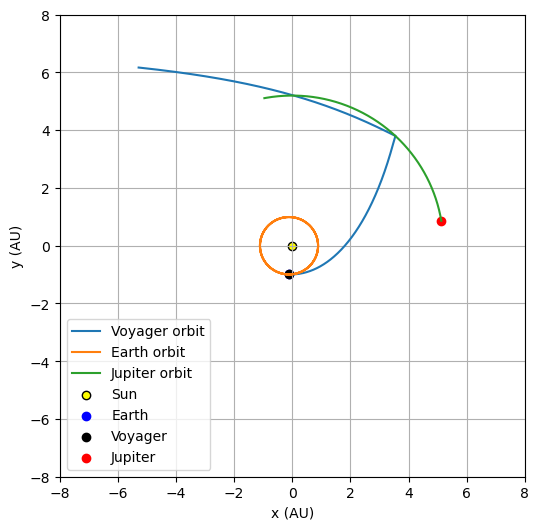

In [60]:
#Initial conditions time
#For Earth
rE = 1.0
theta_E = 4.6
xE = rE * np.cos(theta_E)
yE = rE * np.sin(theta_E)
vE = np.sqrt(G*M_sun/rE)
vxE, vyE = vE, 0.0

#Jupiter
rJ = 5.2
theta_J = 6.45

xJ = rJ*np.cos(theta_J)
yJ = rJ*np.sin(theta_J)
vJ = np.sqrt(G*M_sun/rJ)

vxJ = -vJ*np.sin(theta_J)
vyJ =  vJ*np.cos(theta_J)

#Voyager
xV = xE + eps
yV = yE

# unit vectors at Earth
r_hat_x = xE/np.sqrt(xE**2 + yE**2)
r_hat_y = yE/np.sqrt(xE**2 + yE**2)

t_hat_x = -r_hat_y
t_hat_y =  r_hat_x

#escape Earth boost
delta_v = 0.39*vE
vxV = vxE + delta_v*t_hat_x
vyV = vyE + delta_v*t_hat_y

#actually doing the thing
time = 3
dt = 0.001

xV_vals, yV_vals, xE_vals, yE_vals, xJ_vals, yJ_vals, vxV_vals, vyV_vals, t = Leapfrog_4body(xV, yV, vxV, vyV, xE, yE, vxE, vyE, xJ, yJ, 
                                                                                             vxJ, vyJ, time, dt)

#Getting the minimum distance
dist = np.sqrt((xV_vals - xJ_vals)**2 + (yV_vals - yJ_vals)**2)
min_idx = np.argmin(dist)

#Getting the velocity of Voyager
v = np.sqrt(vxV_vals**2 + vyV_vals**2) * vel_conver

#this piece right here was from chat because what I was seeing in the animation wasn't matching these output values. 
#I do know part of it is the frame rate in the animation, so I can't necessarily use that as the standard
window = 300

i0 = max(min_idx - window, 0)
i1 = min(min_idx + window, len(v))

#ensure non-empty slices
if min_idx > 0:
    v_before = np.mean(v[i0:min_idx])
else:
    v_before = v[0]

if min_idx < len(v) - 1:
    v_after = np.mean(v[min_idx+1:i1])
else:
    v_after = v[-1]

print("Closest distance (AU):", dist[min_idx])
print("Time (months):", t[min_idx]*12)
print("Speed before (km/s):", v_before)
print("Speed after (km/s):", v_after)
print("Delta v (km/s):", v_after - v_before)

plt.figure(figsize=(6,6))
plt.xlim(-8,8)
plt.ylim(-8,8)
plt.plot(xV_vals,yV_vals,label="Voyager orbit")
plt.plot(xE_vals,yE_vals,label="Earth orbit")
plt.plot(xJ_vals,yJ_vals,label="Jupiter orbit")
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(xE,yE,color="blue", label="Earth")
plt.scatter(xV,yV,color="black",label="Voyager",alpha=1,edgecolor="black")
plt.scatter(xJ,yJ,color="red",label="Jupiter")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.show()

In [12]:
#Figure stuff
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_xlabel("x (AU)")
ax.set_ylabel("y (AU)")
ax.grid()

#plotting stuff
ax.plot(0, 0, 'yo', markersize=10, label="Sun")
voyager, = ax.plot([], [], 'ko', markersize=4, label="Voyager")
earth,   = ax.plot([], [], 'go', markersize=5, label="Earth")
jupiter, = ax.plot([], [], 'ro', markersize=5, label="Jupiter")
vtrail, = ax.plot([], [], 'k-', alpha=0.5)
etrail, = ax.plot([], [], 'g-', alpha=0.5)
jtrail, = ax.plot([], [], 'r-', alpha=0.5)

ax.legend()


def init():
    voyager.set_data([], [])
    earth.set_data([], [])
    jupiter.set_data([], [])

    vtrail.set_data([], [])
    etrail.set_data([], [])
    jtrail.set_data([], [])

    return voyager, earth, jupiter, vtrail, etrail, jtrail

#Update function
frame_step = 15

def update(frame):
    idx = min(frame * frame_step, len(xV_vals) - 1)

    voyager.set_data([xV_vals[idx]], [yV_vals[idx]])
    earth.set_data([xE_vals[idx]], [yE_vals[idx]])
    jupiter.set_data([xJ_vals[idx]], [yJ_vals[idx]])

    vtrail.set_data(xV_vals[:idx], yV_vals[:idx])
    etrail.set_data(xE_vals[:idx], yE_vals[:idx])
    jtrail.set_data(xJ_vals[:idx], yJ_vals[:idx])

    ax.set_title(f"Voyager Flyby: t = {t[idx]*12:.1f} months | v = {v[idx]:.2f} km/s")

    return voyager, earth, jupiter, vtrail, etrail, jtrail


total_frames = len(xV_vals) // frame_step
ani = FuncAnimation(fig,update,frames=total_frames,init_func=init,blit=True,interval=20)
plt.close()

#save as gif
ani.save("voyager.gif", writer="pillow", fps=30)